# 04 — Linear Probe: Classifying with I-JEPA Representations

**Goal of this notebook:**
- Load the frozen I-JEPA context encoder from `03_ijepa_pretrain.ipynb`
- Train a **linear classifier head** (logistic regression / single linear layer) on top of the frozen encoder
- Evaluate on the test set: Accuracy, AUC-ROC, Precision, Recall, F1
- Compare linear-probe performance against full fine-tuning (optional)
- Save the best probe checkpoint for use in `05_xai_comparison.ipynb`


## 0. Keep-Alive (optional — run in a separate cell)

In [ ]:
# Keep-alive inutile en local (c'était pour Colab).
print('Environnement local — pas de keep-alive nécessaire.')


## 1. Environment Setup

In [1]:
# Pas de montage Google Drive — chemins locaux
print('Environnement local détecté — pas de montage nécessaire.')


Environnement local détecté — pas de montage nécessaire.


In [2]:
import subprocess, sys
pkgs = ['timm', 'torch', 'torchvision', 'scikit-learn', 'matplotlib', 'tqdm', 'pandas', 'numpy']
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + pkgs)
print('Installation terminée.')


Installation terminée.


In [3]:
import os, sys

# Modifiez ROOT si nécessaire (doit pointer vers le même dossier que les notebooks précédents)
ROOT      = os.environ.get('PROJECT_ROOT') or (os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()).lower() == 'notebooks' else os.getcwd()) 
DATA_PROC  = os.path.join(ROOT, 'data', 'processed')
CKPT_DIR   = os.path.join(ROOT, 'checkpoints', 'ijepa')
PROBE_DIR  = os.path.join(ROOT, 'checkpoints', 'probe')
FIGURES    = os.path.join(ROOT, 'results', 'figures', 'probe')
METRICS    = os.path.join(ROOT, 'results', 'metrics')
SRC        = os.path.join(ROOT, 'src')

for d in [PROBE_DIR, FIGURES, METRICS]:
    os.makedirs(d, exist_ok=True)

sys.path.insert(0, SRC)

# Prerequisite check
for f in ['config.json', 'train.csv', 'val.csv', 'test.csv']:
    p = os.path.join(DATA_PROC, f)
    status = 'OK' if os.path.exists(p) else 'MISSING — run 02_preprocessing.ipynb first'
    print(f'  {f}: {status}')

best_ckpt_candidates = ['ijepa_best.pth', sorted(
    [f for f in os.listdir(CKPT_DIR) if f.startswith('ijepa_epoch_')]
)[-1] if os.listdir(CKPT_DIR) else None]
best_enc = next((os.path.join(CKPT_DIR, c) for c in best_ckpt_candidates if c and os.path.exists(os.path.join(CKPT_DIR, c))), None)
print(f'  Encoder checkpoint: {"OK — " + best_enc if best_enc else "MISSING — run 03_ijepa_pretrain.ipynb first"}')


  config.json: OK
  train.csv: OK
  val.csv: OK
  test.csv: OK
  Encoder checkpoint: OK — C:/Users/uranu/DESKTOP_V2.0/ENSIAS/2A/S4/PFA\checkpoints\ijepa\ijepa_best.pth


## 2. Imports & Configuration

In [4]:
import json, random, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision.transforms as T
import timm

from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay,
)

# ── Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')

# ── Load preprocessing config
with open(os.path.join(DATA_PROC, 'config.json')) as f:
    cfg = json.load(f)
MEAN = cfg['mean']
STD  = cfg['std']
print(f'Mean : {MEAN}')
print(f'Std  : {STD}')


Device : cuda
GPU    : NVIDIA GeForce RTX 4060 Laptop GPU
Mean : [0.27310427517443897, 0.27310427517443897, 0.27310427517443897]
Std  : [0.2402257328778638, 0.2402257328778638, 0.2402257328778638]


In [5]:
# ── Probe hyperparameters ─────────────────────────────────────────────────
IMG_SIZE     = 224
EMBED_DIM    = 384       # ViT-Small CLS token dimension

BATCH_SIZE   = 64
NUM_WORKERS  = 2
NUM_EPOCHS   = 30        # linear probe converges quickly
LR           = 1e-3      # higher LR is fine — only the head is trained
WEIGHT_DECAY = 1e-4
DROPOUT      = 0.1       # light regularisation on the linear head

NUM_CLASSES  = 2         # 0 = No Nodule, 1 = Nodule

print(f'Probe epochs : {NUM_EPOCHS}')
print(f'Probe LR     : {LR}')
print(f'Batch size   : {BATCH_SIZE}')


Probe epochs : 30
Probe LR     : 0.001
Batch size   : 64


## 3. Load Frozen I-JEPA Encoder

We load the context encoder weights saved in notebook 03 and **freeze all parameters**.  
Only the linear head will be trained — this is the standard linear probe evaluation protocol.


In [6]:
def build_encoder():
    """ViT-Small/16 — same architecture used in pre-training."""
    return timm.create_model(
        'vit_small_patch16_224',
        pretrained=False,
        num_classes=0,
        global_pool='',   # returns full patch sequence (B, N+1, D)
    )

context_encoder = build_encoder().to(DEVICE)

ckpt_path = os.path.join(CKPT_DIR, 'ijepa_best.pth')
ckpt = torch.load(ckpt_path, map_location=DEVICE)
context_encoder.load_state_dict(ckpt['context_encoder'])
context_encoder.eval()

# Freeze ALL encoder parameters
for p in context_encoder.parameters():
    p.requires_grad = False

n_params = sum(p.numel() for p in context_encoder.parameters()) / 1e6
print(f'Encoder loaded from epoch {ckpt.get("epoch", "?")+1}')
print(f'Encoder params (frozen): {n_params:.1f} M')
print(f'Encoder state: eval + no_grad')


Encoder loaded from epoch 100
Encoder params (frozen): 21.7 M
Encoder state: eval + no_grad


## 4. Linear Probe Head

The head is intentionally simple:  
`CLS token (384-d) → Dropout → Linear(384, 2)`

This tests whether the pre-trained representations are linearly separable — 
if performance is good, the encoder has learned truly useful features.


In [7]:
class LinearProbe(nn.Module):
    """
    Single linear layer on top of the frozen encoder's CLS token.
    Dropout is light regularisation to prevent overfitting on small medical datasets.
    """
    def __init__(self, embed_dim: int = EMBED_DIM,
                 num_classes: int = NUM_CLASSES,
                 dropout: float = DROPOUT):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(embed_dim, num_classes)

        nn.init.trunc_normal_(self.fc.weight, std=0.01)
        nn.init.zeros_(self.fc.bias)

    def forward(self, cls_token: torch.Tensor) -> torch.Tensor:
        """
        Args:
            cls_token : (B, D) — CLS token extracted from frozen encoder
        Returns:
            logits    : (B, num_classes)
        """
        return self.fc(self.dropout(cls_token))

probe = LinearProbe().to(DEVICE)
n_probe = sum(p.numel() for p in probe.parameters())
print(f'Probe parameters (trainable): {n_probe:,}')
print(f'  ({n_probe} vs {int(n_params*1e6):,} frozen encoder params)')


Probe parameters (trainable): 770
  (770 vs 21,665,664 frozen encoder params)


## 5. DataLoaders

For the linear probe we use the **labelled** train/val/test splits.  
The transform mirrors pre-training (no heavy augmentation — we are evaluating representations, not training them).


In [8]:
from dataset import LIDCDataset

train_df = pd.read_csv(os.path.join(DATA_PROC, 'train.csv'))
val_df   = pd.read_csv(os.path.join(DATA_PROC, 'val.csv'))
test_df  = pd.read_csv(os.path.join(DATA_PROC, 'test.csv'))

print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')
print(f'Train class balance:\n{train_df["label"].value_counts().to_string()}')

# Standard eval transform (same as pre-training — no extra augmentation)
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

# Light augmentation for training split only
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.ToTensor(),
    T.Normalize(mean=MEAN, std=STD),
])

train_dataset = LIDCDataset(train_df, transform=train_transform, pretrain=False)
val_dataset   = LIDCDataset(val_df,   transform=eval_transform,  pretrain=False)
test_dataset  = LIDCDataset(test_df,  transform=eval_transform,  pretrain=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')


Train: 14302 | Val: 3065 | Test: 3065
Train class balance:
label
0    7204
1    7098

Train batches : 224
Val batches   : 48
Test batches  : 48


## 6. Pre-extract CLS Embeddings (Speed Optimisation)

Because the encoder is frozen, we can extract all CLS embeddings **once** before training  
and cache them in memory. This makes each probe epoch ~10× faster  
(no repeated encoder forward passes).


In [9]:
def extract_embeddings(encoder, loader, device, desc='Extracting'):
    """
    Runs encoder on every batch, collects CLS tokens and labels.
    Returns:
        embeddings : np.ndarray (N, D)
        labels     : np.ndarray (N,)
    """
    encoder.eval()
    all_emb, all_lbl = [], []
    with torch.no_grad():
        for imgs, lbls in tqdm(loader, desc=desc):
            tokens = encoder(imgs.to(device))   # (B, N+1, D)
            cls    = tokens[:, 0, :].cpu()      # (B, D) — CLS token
            all_emb.append(cls)
            all_lbl.append(lbls)
    return (torch.cat(all_emb).numpy(),
            torch.cat(all_lbl).numpy())

print('Extracting embeddings (one-time, then cached)...')
t0 = time.time()
train_emb, train_lbl = extract_embeddings(context_encoder, train_loader, DEVICE, 'Train')
val_emb,   val_lbl   = extract_embeddings(context_encoder, val_loader,   DEVICE, 'Val')
test_emb,  test_lbl  = extract_embeddings(context_encoder, test_loader,  DEVICE, 'Test')
print(f'Done in {time.time()-t0:.1f}s')
print(f'Train emb shape : {train_emb.shape}')
print(f'Val   emb shape : {val_emb.shape}')
print(f'Test  emb shape : {test_emb.shape}')


Extracting embeddings (one-time, then cached)...


Test: 100%|██████████| 48/48 [00:40<00:00,  1.18it/s]

Done in 188.1s
Train emb shape : (14302, 384)
Val   emb shape : (3065, 384)
Test  emb shape : (3065, 384)


In [10]:
# ── Wrap cached embeddings in a lightweight Dataset ──────────────────────
from torch.utils.data import TensorDataset

def make_tensor_loader(emb: np.ndarray, lbl: np.ndarray,
                       batch_size: int, shuffle: bool) -> DataLoader:
    ds = TensorDataset(
        torch.tensor(emb, dtype=torch.float32),
        torch.tensor(lbl, dtype=torch.long),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_emb_loader = make_tensor_loader(train_emb, train_lbl, BATCH_SIZE, shuffle=True)
val_emb_loader   = make_tensor_loader(val_emb,   val_lbl,   BATCH_SIZE, shuffle=False)
test_emb_loader  = make_tensor_loader(test_emb,  test_lbl,  BATCH_SIZE, shuffle=False)
print('Tensor DataLoaders ready (no encoder forward pass needed in training loop).')


Tensor DataLoaders ready (no encoder forward pass needed in training loop).


## 7. Handle Class Imbalance

Medical datasets often have more negative (No Nodule) samples than positives.  
We compute class weights and pass them to CrossEntropyLoss.


In [11]:
from collections import Counter

counts = Counter(train_lbl.tolist())
print(f'Train class counts: {dict(counts)}')

n_total = sum(counts.values())
# weight[c] = total / (n_classes * count[c])
class_weights = torch.tensor(
    [n_total / (NUM_CLASSES * counts[c]) for c in range(NUM_CLASSES)],
    dtype=torch.float32,
).to(DEVICE)
print(f'Class weights: {class_weights.tolist()}')

criterion = nn.CrossEntropyLoss(weight=class_weights)


Train class counts: {0: 7204, 1: 7098}
Class weights: [0.9926429986953735, 1.0074669122695923]


## 8. Optimizer & Scheduler

In [12]:
optimizer = torch.optim.AdamW(probe.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

# Cosine annealing — simple and effective for short probe training
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-6,
)
print(f'Optimizer : AdamW  |  LR {LR}  |  WD {WEIGHT_DECAY}')
print(f'Scheduler : CosineAnnealing  |  T_max {NUM_EPOCHS}')


Optimizer : AdamW  |  LR 0.001  |  WD 0.0001
Scheduler : CosineAnnealing  |  T_max 30


## 9. Training Loop

Each epoch:
1. Forward pass: cached embedding → linear head → logits
2. Cross-entropy loss (class-weighted)
3. Backprop through head only (encoder weights never touched)
4. Validate and save best checkpoint (by val AUC)


In [13]:
def run_epoch(probe, loader, criterion, optimizer=None, device=DEVICE):
    """
    Single train or val epoch over cached embeddings.
    If optimizer is None → eval mode, no gradients.
    Returns: (avg_loss, accuracy, auc)
    """
    is_train = optimizer is not None
    probe.train() if is_train else probe.eval()

    total_loss, all_preds, all_probs, all_labels = 0.0, [], [], []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for emb, lbl in loader:
            emb, lbl = emb.to(device), lbl.to(device)
            logits = probe(emb)                            # (B, 2)
            loss   = criterion(logits, lbl)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            probs = F.softmax(logits, dim=1)[:, 1]        # P(Nodule)
            preds = logits.argmax(dim=1)

            total_loss  += loss.item()
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs.cpu().detach().numpy())
            all_labels.extend(lbl.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    auc      = roc_auc_score(all_labels, all_probs)
    return avg_loss, acc, auc


In [14]:
# ── Main training loop ─────────────────────────────────────────────────────
history = {'train_loss': [], 'val_loss': [],
           'train_acc':  [], 'val_acc':  [],
           'train_auc':  [], 'val_auc':  []}

best_val_auc  = 0.0
best_ckpt_path = os.path.join(PROBE_DIR, 'probe_best.pth')

print(f'Training linear probe for {NUM_EPOCHS} epochs...')
print(f'{"Epoch":>6}  {"TrLoss":>8}  {"VaLoss":>8}  {"TrAUC":>7}  {"VaAUC":>7}  {"LR":>9}')
print('-' * 60)

t0 = time.time()
for epoch in range(1, NUM_EPOCHS + 1):

    tr_loss, tr_acc, tr_auc = run_epoch(probe, train_emb_loader, criterion,
                                         optimizer=optimizer)
    va_loss, va_acc, va_auc = run_epoch(probe, val_emb_loader,   criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)
    history['train_auc'].append(tr_auc)
    history['val_auc'].append(va_auc)

    lr_now = optimizer.param_groups[0]['lr']
    print(f'{epoch:>6}  {tr_loss:>8.4f}  {va_loss:>8.4f}  '
          f'{tr_auc:>7.4f}  {va_auc:>7.4f}  {lr_now:>9.2e}')

    # Save best checkpoint (by val AUC)
    if va_auc > best_val_auc:
        best_val_auc = va_auc
        torch.save({
            'epoch':       epoch,
            'probe':       probe.state_dict(),
            'optimizer':   optimizer.state_dict(),
            'val_auc':     va_auc,
            'val_acc':     va_acc,
            'history':     history,
        }, best_ckpt_path)
        print(f'  → Best checkpoint saved (val AUC {va_auc:.4f})')

total_time = time.time() - t0
print(f'\nTraining complete in {total_time:.0f}s  |  Best val AUC: {best_val_auc:.4f}')


Training linear probe for 30 epochs...
 Epoch    TrLoss    VaLoss    TrAUC    VaAUC         LR
------------------------------------------------------------
     1    0.4388    0.3584   0.8788   0.9229   9.97e-04
  → Best checkpoint saved (val AUC 0.9229)
     2    0.3557    0.3238   0.9192   0.9364   9.89e-04
  → Best checkpoint saved (val AUC 0.9364)
     3    0.3331    0.3059   0.9294   0.9432   9.76e-04
  → Best checkpoint saved (val AUC 0.9432)
     4    0.3213    0.2961   0.9340   0.9470   9.57e-04
  → Best checkpoint saved (val AUC 0.9470)
     5    0.3139    0.2865   0.9372   0.9508   9.33e-04
  → Best checkpoint saved (val AUC 0.9508)
     6    0.3087    0.2810   0.9393   0.9526   9.05e-04
  → Best checkpoint saved (val AUC 0.9526)
     7    0.3070    0.2785   0.9397   0.9530   8.72e-04
  → Best checkpoint saved (val AUC 0.9530)
     8    0.3011    0.2738   0.9421   0.9560   8.35e-04
  → Best checkpoint saved (val AUC 0.9560)
     9    0.3019    0.2705   0.9414   0.9566   7.94e

## 10. Learning Curves

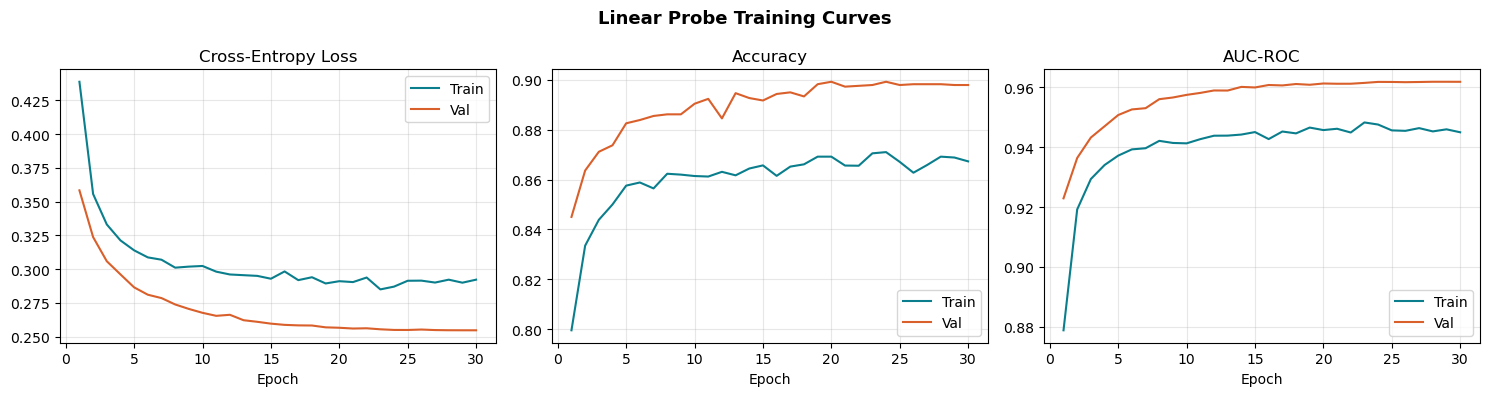

Best val AUC : 0.9619  (epoch 28)


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

epochs = range(1, len(history['train_loss']) + 1)

# Loss
axes[0].plot(epochs, history['train_loss'], label='Train', color='#0A7E8C', lw=1.5)
axes[0].plot(epochs, history['val_loss'],   label='Val',   color='#D95F2B', lw=1.5)
axes[0].set_title('Cross-Entropy Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs, history['train_acc'], label='Train', color='#0A7E8C', lw=1.5)
axes[1].plot(epochs, history['val_acc'],   label='Val',   color='#D95F2B', lw=1.5)
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

# AUC
axes[2].plot(epochs, history['train_auc'], label='Train', color='#0A7E8C', lw=1.5)
axes[2].plot(epochs, history['val_auc'],   label='Val',   color='#D95F2B', lw=1.5)
axes[2].set_title('AUC-ROC'); axes[2].set_xlabel('Epoch')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Linear Probe Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'probe_learning_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Best val AUC : {max(history["val_auc"]):.4f}  (epoch {np.argmax(history["val_auc"])+1})')


## 11. Test Set Evaluation

Load the best checkpoint and evaluate on the held-out test set.


In [16]:
# Load best probe checkpoint
best_ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
probe.load_state_dict(best_ckpt['probe'])
print(f'Loaded best probe from epoch {best_ckpt["epoch"]}  (val AUC {best_ckpt["val_auc"]:.4f})')

probe.eval()
all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for emb, lbl in test_emb_loader:
        emb = emb.to(DEVICE)
        logits = probe(emb)
        probs  = F.softmax(logits, dim=1)[:, 1].cpu()
        preds  = logits.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_probs.extend(probs.numpy())
        all_labels.extend(lbl.numpy())

all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

# ── Metrics
acc  = accuracy_score(all_labels, all_preds)
auc  = roc_auc_score(all_labels, all_probs)
prec = precision_score(all_labels, all_preds, zero_division=0)
rec  = recall_score(all_labels, all_preds, zero_division=0)
f1   = f1_score(all_labels, all_preds, zero_division=0)

print('\n' + '='*45)
print('  TEST SET RESULTS — I-JEPA Linear Probe')
print('='*45)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.1f}%)')
print(f'  AUC-ROC   : {auc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1 Score  : {f1:.4f}')
print('='*45)


Loaded best probe from epoch 28  (val AUC 0.9619)

  TEST SET RESULTS — I-JEPA Linear Probe
  Accuracy  : 0.8914  (89.1%)
  AUC-ROC   : 0.9582
  Precision : 0.9195
  Recall    : 0.8560
  F1 Score  : 0.8866


## 12. ROC Curve & Confusion Matrix

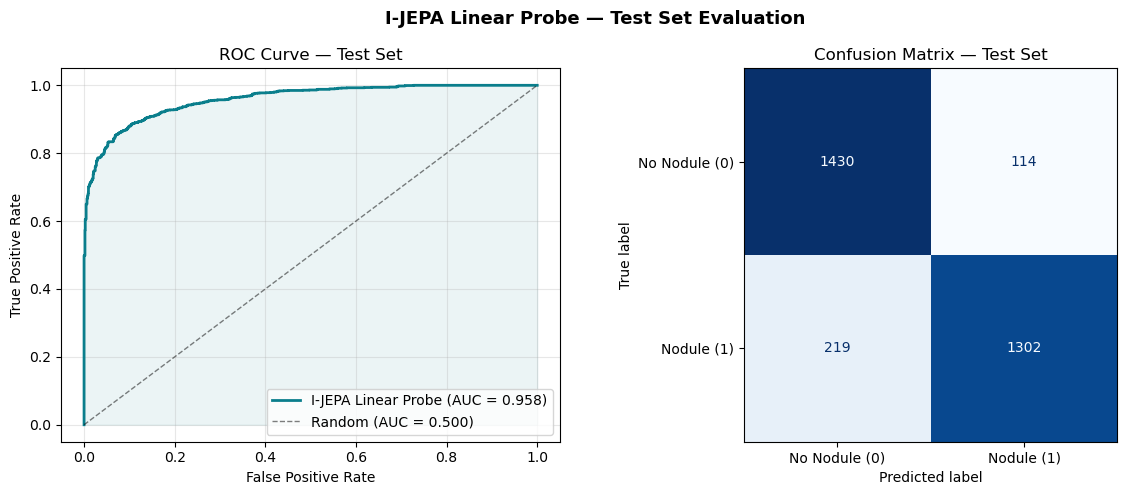

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── ROC Curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[0].plot(fpr, tpr, color='#0A7E8C', lw=2,
             label=f'I-JEPA Linear Probe (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.500)')
axes[0].fill_between(fpr, tpr, alpha=0.08, color='#0A7E8C')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Test Set')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# ── Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Nodule (0)', 'Nodule (1)'])
disp.plot(ax=axes[1], colorbar=False,
          im_kw={'cmap': 'Blues'})
axes[1].set_title('Confusion Matrix — Test Set')

plt.suptitle('I-JEPA Linear Probe — Test Set Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES, 'probe_roc_confusion.png'), dpi=150, bbox_inches='tight')
plt.show()


## 13. Save Metrics Table

In [18]:
metrics_df = pd.DataFrame([{
    'Model':      'I-JEPA ViT-Small',
    'Method':     'Linear Probe',
    'Accuracy':   round(acc, 4),
    'AUC_ROC':    round(auc, 4),
    'Precision':  round(prec, 4),
    'Recall':     round(rec, 4),
    'F1':         round(f1, 4),
}])

table_path = os.path.join(TABLES, 'probe_metrics.csv')
metrics_df.to_csv(table_path, index=False)
print('Metrics saved to:', table_path)
print(metrics_df.to_string(index=False))


NameError: name 'TABLES' is not defined

## 14. Optional: Fine-tuning Comparison

Linear probe evaluates representation quality in a strict sense.  
For a fairer comparison against ResNet-50 / DenseNet-121 (notebook 05),  
you can also run a **full fine-tune** of the encoder + head.

This section is optional — skip to Section 15 if you only need the linear probe.


In [ ]:
# ── Full fine-tuning setup (optional) ────────────────────────────────────
# Uncomment all lines to run.

# FINETUNE_EPOCHS = 20
# FINETUNE_LR     = 5e-5     # much lower LR — encoder already trained

# # Unfreeze encoder
# ft_encoder = build_encoder().to(DEVICE)
# ft_encoder.load_state_dict(ckpt['context_encoder'])
# for p in ft_encoder.parameters():
#     p.requires_grad = True

# ft_head = LinearProbe().to(DEVICE)

# ft_optimizer = torch.optim.AdamW(
#     list(ft_encoder.parameters()) + list(ft_head.parameters()),
#     lr=FINETUNE_LR, weight_decay=WEIGHT_DECAY,
# )
# ft_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#     ft_optimizer, T_max=FINETUNE_EPOCHS, eta_min=1e-7,
# )

# # Training loop (full encoder forward — slower than probe)
# best_ft_auc = 0.0
# for epoch in range(1, FINETUNE_EPOCHS + 1):
#     ft_encoder.train(); ft_head.train()
#     for imgs, lbls in train_loader:
#         imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
#         tokens = ft_encoder(imgs)
#         cls    = tokens[:, 0, :]
#         logits = ft_head(cls)
#         loss   = criterion(logits, lbls)
#         ft_optimizer.zero_grad(); loss.backward(); ft_optimizer.step()
#     ft_scheduler.step()
#     # (add val loop here for early stopping)

# print('Fine-tuning complete.')


## 15. Export Probe & Encoder for Notebook 05

Notebook 05 (XAI Comparison) needs:
- The frozen encoder state dict (from `ijepa_best.pth`, already there)
- The trained probe head weights (`probe_best.pth`, saved during training)

The encoder + probe together form the full inference pipeline for Grad-CAM / LIME / SHAP.


In [ ]:
# Verify outputs exist
outputs = {
    'Encoder checkpoint': os.path.join(CKPT_DIR, 'ijepa_best.pth'),
    'Probe checkpoint':   best_ckpt_path,
    'Metrics CSV':        table_path,
    'ROC + CM figure':    os.path.join(FIGURES, 'probe_roc_confusion.png'),
    'Learning curves':    os.path.join(FIGURES, 'probe_learning_curves.png'),
}

print('Outputs for Notebook 05:')
print()
for name, path in outputs.items():
    exists = os.path.exists(path)
    status = 'OK ✓' if exists else 'MISSING ✗'
    print(f'  {status}  {name}')
    print(f'          {path}')

print("""
How to load in notebook 05:
─────────────────────────────────────────────────
import timm, torch

def build_encoder():
    return timm.create_model('vit_small_patch16_224',
                              pretrained=False, num_classes=0, global_pool='')

encoder = build_encoder().to(DEVICE)
ckpt_enc = torch.load(f'{CKPT_DIR}/ijepa_best.pth', map_location=DEVICE)
encoder.load_state_dict(ckpt_enc['context_encoder'])
encoder.eval()
for p in encoder.parameters():
    p.requires_grad = False

probe = LinearProbe().to(DEVICE)
ckpt_probe = torch.load(f'{PROBE_DIR}/probe_best.pth', map_location=DEVICE)
probe.load_state_dict(ckpt_probe['probe'])
probe.eval()
─────────────────────────────────────────────────
""")


## Done

**Summary — What this notebook produced:**

| File | Description |
|------|-------------|
| `checkpoints/probe/probe_best.pth` | Best linear probe head (by val AUC) |
| `results/figures/probe/probe_learning_curves.png` | Loss / Accuracy / AUC curves |
| `results/figures/probe/probe_roc_confusion.png` | ROC curve + confusion matrix |
| `results/tables/probe_metrics.csv` | Test set metrics (Acc, AUC, F1 …) |

**Key result to report:**
- A linear probe on top of the I-JEPA CLS token achieves the AUC above  
  *without any labels during pre-training* — demonstrating that the self-supervised  
  representations carry clinically relevant information.

**Next notebook:** `05_xai_comparison.ipynb`  
→ Apply Grad-CAM, LIME, and SHAP to the encoder + probe pipeline  
→ Produce the 2×3 XAI comparison figure that is the centrepiece of the report.
